In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import pickle
import pathlib as Path

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import jarque_bera
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings("ignore")

In [2]:
# load data
sys.path.append("../")

from src.data_loader import load_cement_data

df = load_cement_data()
df.head()

,date,site_id,region,behavior,cement_type,planned_pour_tonnes,consumed_tonnes,opening_inventory_tonnes,deliveries_tonnes,closing_inventory_tonnes,rain_mm,avg_temp_c,silo_capacity
0,2022-01-01,SITE_001,North,aggressive,CEM_II,43.18,34.54,52.56,45.83,63.85,3.40,-3.10,448
1,2022-01-02,SITE_001,North,aggressive,CEM_I,45.26,45.26,63.85,19.97,38.56,3.23,14.28,448
2,2022-01-03,SITE_001,North,aggressive,CEM_III,38.69,38.69,38.56,47.19,47.06,2.64,6.40,448
3,2022-01-04,SITE_001,North,aggressive,CEM_I,33.16,33.16,47.06,18.74,32.64,8.25,14.23,448
4,2022-01-05,SITE_001,North,aggressive,CEM_III,56.88,47.04,32.64,14.40,0.00,2.69,8.97,448


In [3]:
# prepare one site for modeling
site_id = 'SITE_001'

site_df = df[df['site_id'] == site_id].copy()
site_df = site_df.set_index('date')
site_df = site_df.sort_values('date')

y = site_df['consumed_tonnes']

x = site_df[['planned_pour_tonnes', 'rain_mm', 'avg_temp_c']]

site_df.head()

,site_id,region,behavior,cement_type,planned_pour_tonnes,consumed_tonnes,opening_inventory_tonnes,deliveries_tonnes,closing_inventory_tonnes,rain_mm,avg_temp_c,silo_capacity
date,,,,,,,,,,,,
2022-01-01,SITE_001,North,aggressive,CEM_II,43.18,34.54,52.56,45.83,63.85,3.40,-3.10,448
2022-01-02,SITE_001,North,aggressive,CEM_I,45.26,45.26,63.85,19.97,38.56,3.23,14.28,448
2022-01-03,SITE_001,North,aggressive,CEM_III,38.69,38.69,38.56,47.19,47.06,2.64,6.40,448
2022-01-04,SITE_001,North,aggressive,CEM_I,33.16,33.16,47.06,18.74,32.64,8.25,14.23,448
2022-01-05,SITE_001,North,aggressive,CEM_III,56.88,47.04,32.64,14.40,0.00,2.69,8.97,448


In [4]:
# split train test data
split_index = int(len(site_df) * 0.8)
y_train, X_train = y.iloc[:split_index], x.iloc[:split_index]
y_test, X_test = y.iloc[split_index:], x.iloc[split_index:]

print(len(y_train), len(y_test))

876 220


In [5]:
# simple GRID search for SARIMAX parameters
best_aic = np.inf
best_order = None
best_seasonal_order = None
best_model = None

for p in (0, 2):
    for d in (0, 2):
        for q in (0, 2):
            for P in (0, 2):
                for D in (0, 2):
                    for Q in (0, 2):
                        try:
                            model = SARIMAX(
                                y_train, 
                                exog=X_train,
                                order=(p, d, q),
                                seasonal_order=(P, D, Q, 7),
                                enforce_stationarity=False,
                                enforce_invertibility=False
                            )

                            results = model.fit(disp=False)

                            if results.aic < best_aic:
                                best_aic = results.aic
                                best_order = (p, d, q)
                                best_seasonal_order = (P, D, Q, 7)
                                best_model = results


                        except:
                            pass

print(f'Best SARIMAX model order: {best_order}, seasonal order: {best_seasonal_order}, AIC: {best_aic}') 

Best SARIMAX model order: (0, 0, 2), seasonal order: (0, 2, 2, 7), AIC: 6696.319002559316


In [6]:
best_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                   consumed_tonnes   No. Observations:                  876
Model:             SARIMAX(0, 0, 2)x(0, 2, 2, 7)   Log Likelihood               -3340.160
Date:                           Fri, 17 Jul 2026   AIC                           6696.319
Time:                                   00:37:27   BIC                           6734.234
Sample:                               01-01-2022   HQIC                          6710.846
                                    - 05-25-2024                                         
Covariance Type:                             opg                                         
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
planned_pour_tonnes     0.5499      0.036     15.395      0.000       0.480       0.620
rain_mm                -0.8958      0.072    -12.501      0.000      -1.036      -0.755
avg_temp_c              0.0560      0.053      1.048      0.295      -0.049       0.161
ma.L1                   0.0920      0.036      2.555      0.011       0.021       0.163
ma.L2                   0.0067      0.035      0.193      0.847      -0.061       0.075
ma.S.L7                -1.9689      2.438     -0.808      0.419      -6.748       2.810
ma.S.L14                0.9688      2.364      0.410      0.682      -3.664       5.601
sigma2                145.8911    353.768      0.412      0.680    -547.482     839.264
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                28.06
Prob(Q):                              0.92   Prob(JB):                         0.00
Heteroskedasticity (H):               0.97   Skew:                            -0.41
Prob(H) (two-sided):                  0.79   Kurtosis:                         2.63
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [7]:
# perform 8 week forecast using the best SARIMAX model

forecast_horizon = 56

y_test_8w = y_test.iloc[:forecast_horizon]
X_test_8w = X_test.iloc[:forecast_horizon]

forecast = best_model.predict(
  start=y_test_8w.index[0],
  end=y_test_8w.index[-1],
  exog=X_test_8w
)

forecast.head()

2024-05-26    32.655666
2024-05-27    40.070521
2024-05-28    13.698890
2024-05-29    28.744347
2024-05-30    35.838829
Freq: D, Name: predicted_mean, dtype: float64

In [ ]:
# Metrics for SARIMAX model for SITE_001

mask = y_test_8w != 0

mape = np.mean(
  np.abs((y_test_8w[mask] - forecast[mask]) / y_test_8w[mask])
) * 100

rmse = np.sqrt(
  mean_squared_error(y_test_8w[mask], forecast[mask])
)

print("MAPE:", round(mape, 2))
print("RMSE:", round(rmse, 2))

MAPE: 53.88
RMSE: 13.21


In [15]:
# Sarimax metrics for all sites
sarimax_sites_metrics = []
sarimax_sites_predictions = []

for site_id in df['site_id'].unique():
  try:
    site_df = df[df['site_id'] == site_id].copy()
    site_df = site_df.set_index('date')
    site_df = site_df.sort_values('date')

    y = site_df['consumed_tonnes']
    x = site_df[['planned_pour_tonnes', 'rain_mm', 'avg_temp_c']]

    split_index = int(len(site_df) * 0.8)
    y_train, X_train = y.iloc[:split_index], x.iloc[:split_index]
    y_test, X_test = y.iloc[split_index:], x.iloc[split_index:]

    sarimax_model = SARIMAX(
        y_train, 
        exog=X_train,
        order=best_order,
        seasonal_order=best_seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    results = sarimax_model.fit(disp=False)

    forecast_horizon = 56

    y_test_8w = y_test.iloc[:forecast_horizon]
    X_test_8w = X_test.iloc[:forecast_horizon]

    forecast = results.predict(
      start=y_test_8w.index[0],
      end=y_test_8w.index[-1],
      exog=X_test_8w
    )

    site_predictions = pd.DataFrame({
      'site_id': site_id,
      'date': y_test_8w.index,
      'actual_consumed_tonnes': y_test_8w.values,
      'forecasted_consumed_tonnes': forecast.values
    })

    sarimax_sites_predictions.append(site_predictions)

    mask = y_test_8w != 0

    mape = np.mean(
      np.abs((y_test_8w[mask] - forecast[mask]) / y_test_8w[mask])
    ) * 100

    rmse = np.sqrt(
      mean_squared_error(y_test_8w[mask], forecast[mask])
    )

    sarimax_sites_metrics.append({
      'site_id': site_id,
      'MAPE': round(mape, 2),
      'RMSE': round(rmse, 2)
    })

  except Exception as e:
    print(f"Error processing site {site_id}: {e}")

sarimax_sites_metrics_df = pd.DataFrame(sarimax_sites_metrics)

overall_mape = sarimax_sites_metrics_df['MAPE'].mean()
overall_rmse = sarimax_sites_metrics_df['RMSE'].mean()

overall_row = pd.DataFrame([{
    'site_id': 'Overall',
    'MAPE': round(overall_mape, 2),
    'RMSE': round(overall_rmse, 2)
}])

sarimax_sites_metrics_df = pd.concat(
  [sarimax_sites_metrics_df, overall_row], 
  ignore_index=True
)

sarimax_sites_metrics_df 

sarimax_sites_predictions_df = pd.concat(
  sarimax_sites_predictions, 
  ignore_index=True
)

sarimax_sites_predictions_df

,site_id,date,actual_consumed_tonnes,forecasted_consumed_tonnes
0,SITE_001,2024-05-26,54.68,32.655666
1,SITE_001,2024-05-27,28.18,40.070521
2,SITE_001,2024-05-28,0.00,13.698890
3,SITE_001,2024-05-29,40.29,28.744347
4,SITE_001,2024-05-30,32.99,35.838829
...,...,...,...,...
1675,SITE_030,2024-07-16,34.03,25.636905
1676,SITE_030,2024-07-17,14.82,34.600801
1677,SITE_030,2024-07-18,40.22,39.669121
1678,SITE_030,2024-07-19,38.43,29.774230


In [16]:
sarimax_sites_metrics_df

,site_id,MAPE,RMSE
0,SITE_001,53.88,13.21
1,SITE_002,3.78,0.50
2,SITE_003,27.52,10.44
3,SITE_004,3.35,0.44
4,SITE_005,30.60,11.85
5,SITE_006,25.61,10.04
6,SITE_007,37.55,10.95
7,SITE_008,35.72,11.57
8,SITE_009,3.37,0.48
9,SITE_010,45.32,13.46


In [17]:
# Top 3 sites by total Consumed Tonnes
top_3_sites = (
  df.groupby('site_id')['consumed_tonnes']
  .sum()
  .sort_values(ascending=False)
  .head(3)
  .index
)

top_3_sites 

Index(['SITE_025', 'SITE_010', 'SITE_018'], dtype='object', name='site_id')

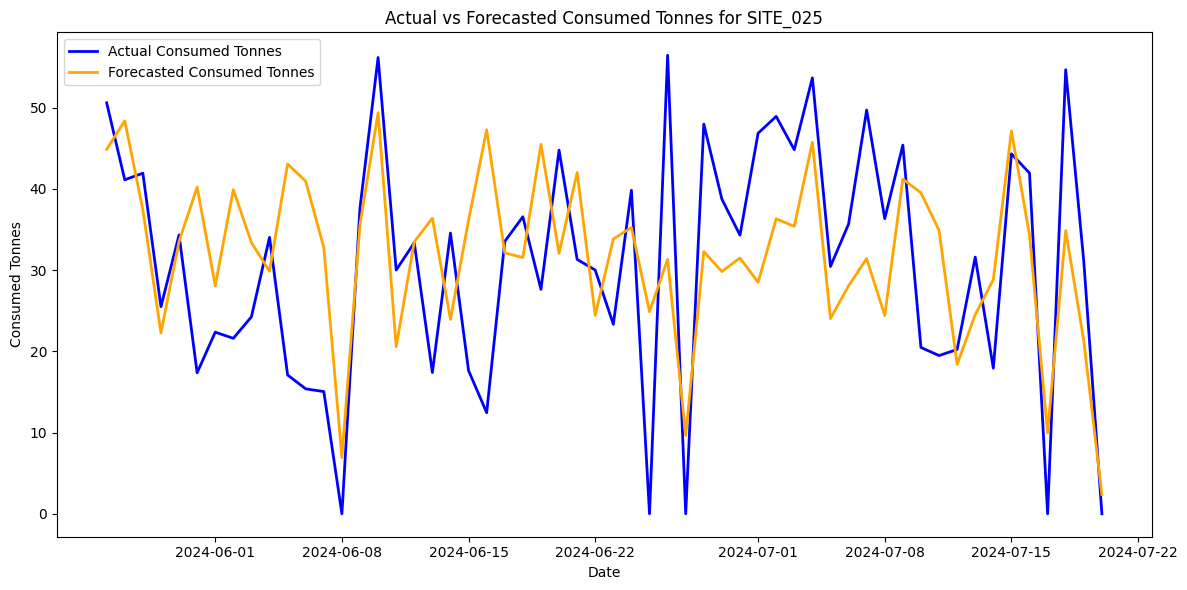

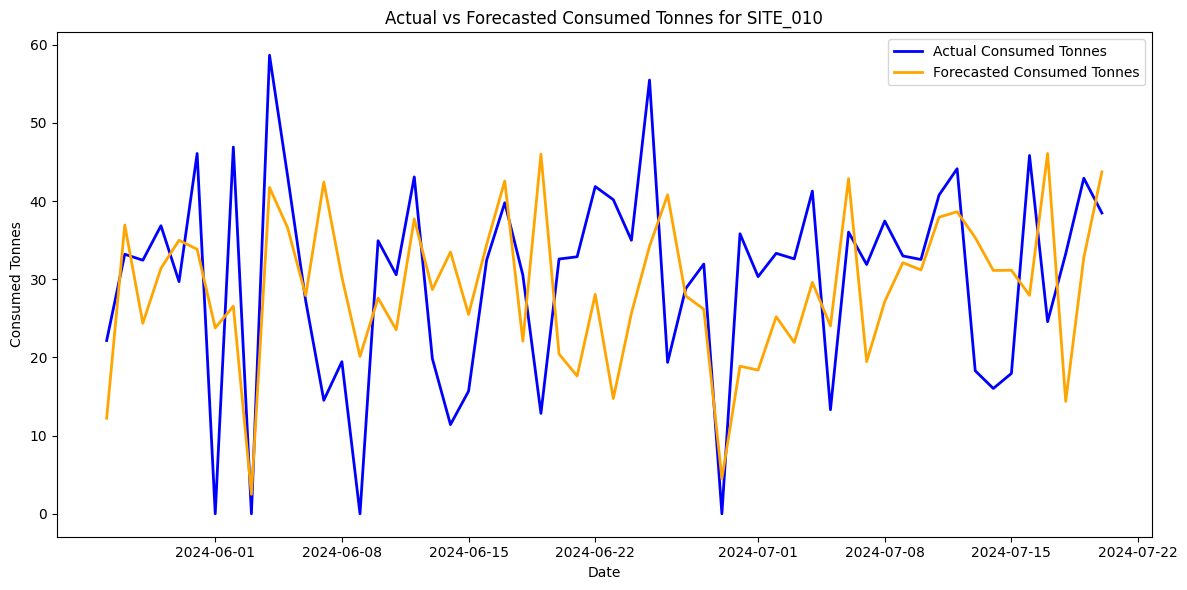

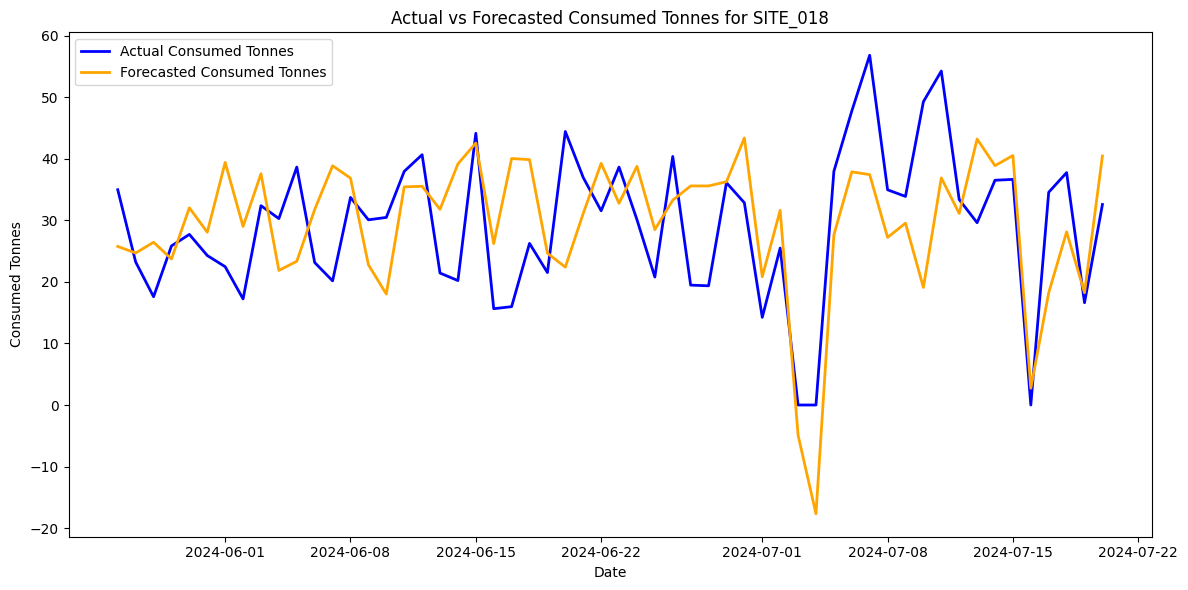

In [20]:
# Visualize predictions vs actuals for top 3 sites
for site_id in top_3_sites:
  plot_df = sarimax_sites_predictions_df[
    sarimax_sites_predictions_df['site_id'] == site_id
  ].copy()

  plot_df = plot_df.set_index('date')

  plt.figure(figsize=(12, 6))

  plt.plot(
    plot_df.index,
    plot_df["actual_consumed_tonnes"],
    label="Actual Consumed Tonnes",
    linewidth=2,
    color='blue'
  )
  plt.plot(
    plot_df.index,
    plot_df["forecasted_consumed_tonnes"],
    label="Forecasted Consumed Tonnes",
    linewidth=2,
    color='orange'
  )

  plt.title(f"Actual vs Forecasted Consumed Tonnes for {site_id}")
  plt.xlabel("Date")
  plt.ylabel("Consumed Tonnes")
  plt.legend()
  plt.tight_layout()
  plt.show()

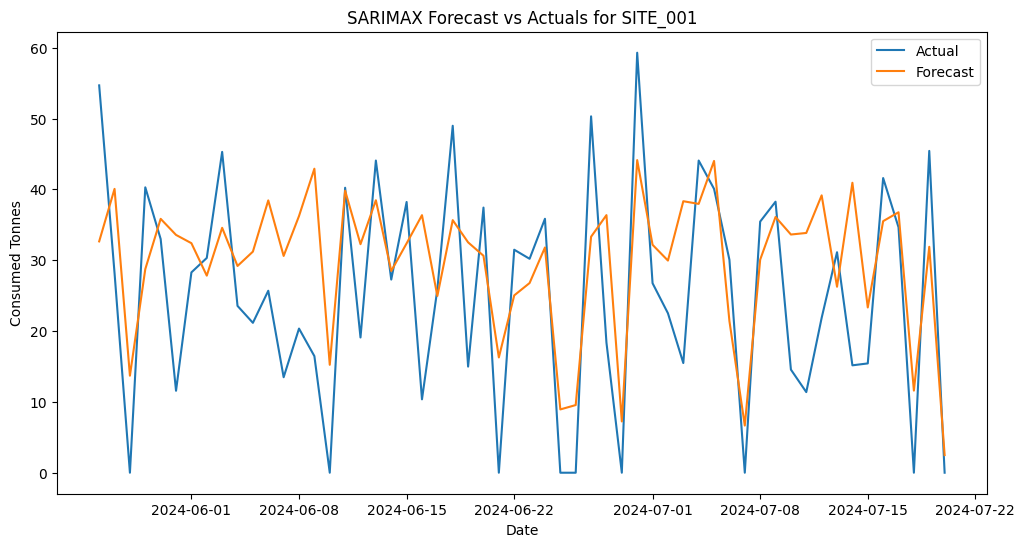

In [9]:
# Plot forecast vs actuals

plt.figure(figsize=(12, 6))

plt.plot(y_test_8w.index, y_test_8w, label='Actual')
plt.plot(y_test_8w.index, forecast, label='Forecast')

plt.title(f'SARIMAX Forecast vs Actuals for {site_id}')
plt.xlabel('Date')
plt.ylabel('Consumed Tonnes')
plt.legend()
plt.show()

In [21]:
# Model diagnostics
# get residuals
residuals = best_model.resid

# Ljung-Box test for autocorrelation
lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)

# Jarque-Bera test for normality
jb_stat, jb_pvalue = jarque_bera(residuals)

# Diagnostic summary table
diagnostic_summary = pd.DataFrame({
  "diagnostic": [
    "Residuals Mean",
    "Residual Standard Deviation",
    "ljung_box p-value (10 lags)",
    "jarque_bera statistic",
    "jarque_bera p-value"
  ],
  "value": [
    residuals.mean(),
    residuals.std(),
    lb_test['lb_pvalue'].iloc[0],
    jb_stat,
    jb_pvalue
  ]
})

diagnostic_summary

,diagnostic,value
0,Residuals Mean,0.124986
1,Residual Standard Deviation,13.213435
2,ljung_box p-value (10 lags),0.573660
3,jarque_bera statistic,14.316922
4,jarque_bera p-value,0.000778


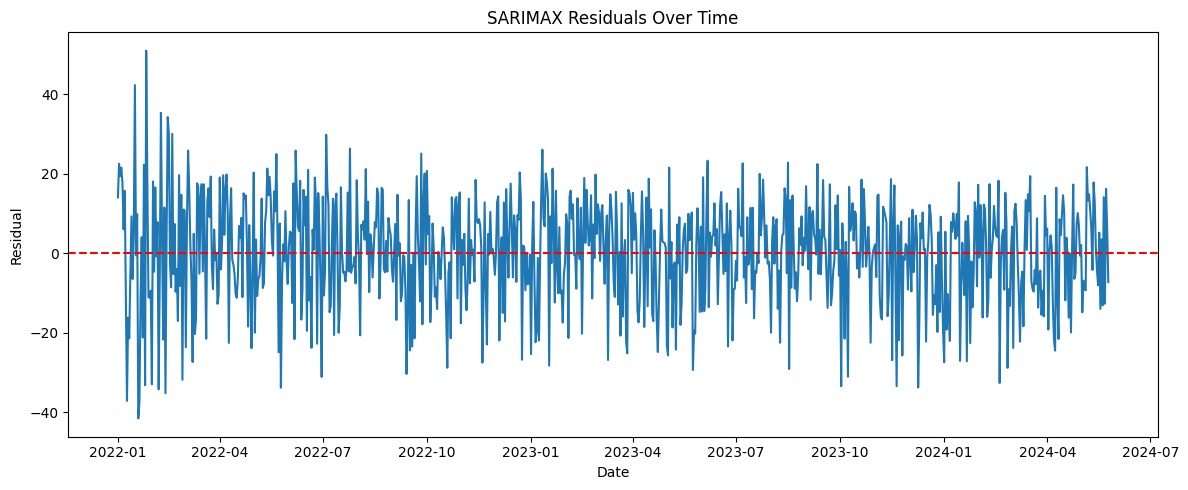

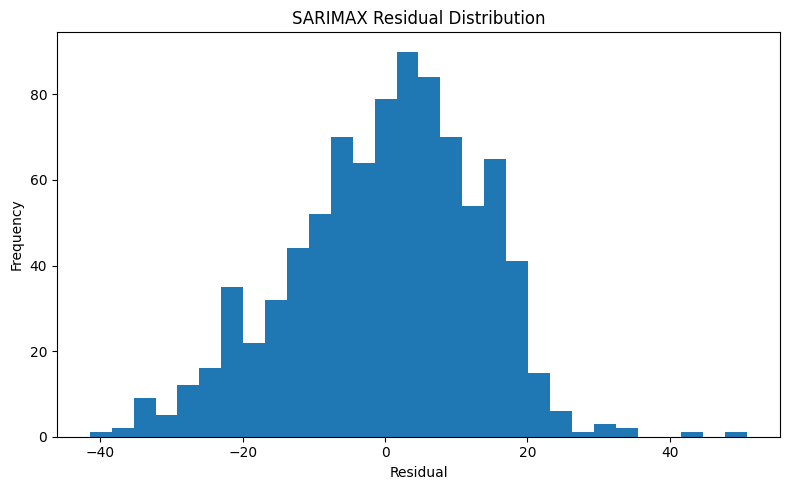

In [22]:
plt.figure(figsize=(12, 5))
plt.plot(residuals)
plt.axhline(0, color="red", linestyle="--")
plt.title("SARIMAX Residuals Over Time")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=30)
plt.title("SARIMAX Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [23]:
print("Ljung-Box p-value:", lb_test["lb_pvalue"].iloc[0])

if lb_test["lb_pvalue"].iloc[0] > 0.05:
    print("Residuals show no strong evidence of autocorrelation.")
else:
    print("Residuals may still contain autocorrelation.")


print("Jarque-Bera p-value:", jb_pvalue)

if jb_pvalue > 0.05:
    print("Residuals are approximately normally distributed.")
else:
    print("Residuals are likely not normally distributed.")

Ljung-Box p-value: 0.5736595902113579
Residuals show no strong evidence of autocorrelation.
Jarque-Bera p-value: 0.0007782513796037254
Residuals are likely not normally distributed.


In [11]:
# xgboost model
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [12]:
y_pred = model.predict(X_test)

In [13]:
mean = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mean)

print("MAPE:", round(mape, 2))
print("RMSE:", round(rmse, 2))

MAPE: 53.88
RMSE: 10.48
